In [4]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['AppleGothic']


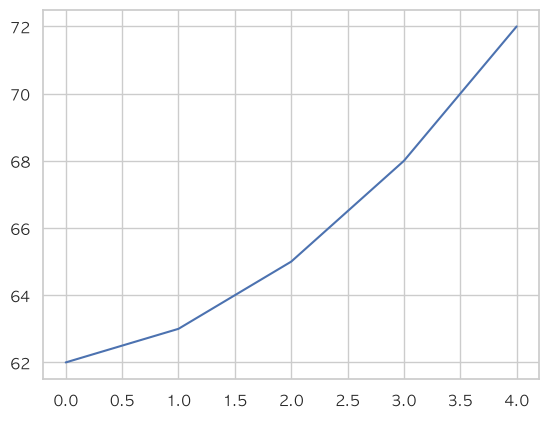

In [5]:
plt.plot([62, 63, 65, 68, 72])
plt.show()
# x축은 0,1,2,3,4 자동

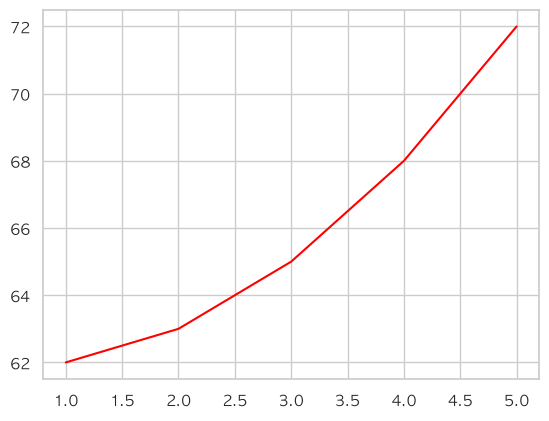

In [6]:
plt.plot([1,2,3,4,5], [62,63,65,68,72], color='red')
plt.show()

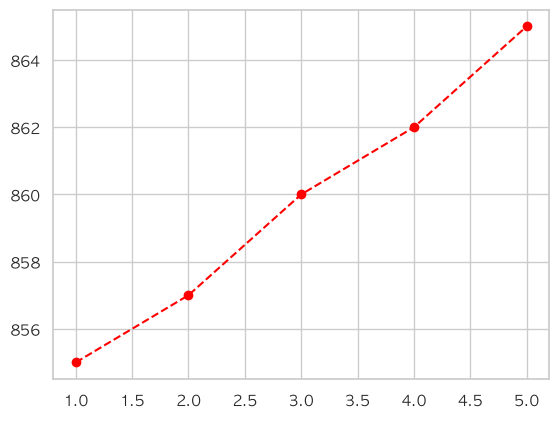

In [7]:
x = [1, 2, 3, 4, 5]
y = [855, 857, 860, 862, 865]
plt.plot(x, y, color='red', linestyle='--', marker='o')
plt.show()

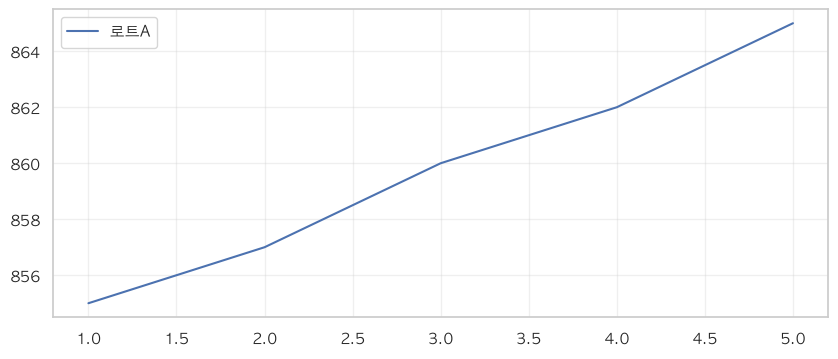

In [8]:
plt.figure(figsize=(10, 4)) # 찾아봅시다. 숙제 ㅠㅠ
plt.plot(x, y, label='로트A')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

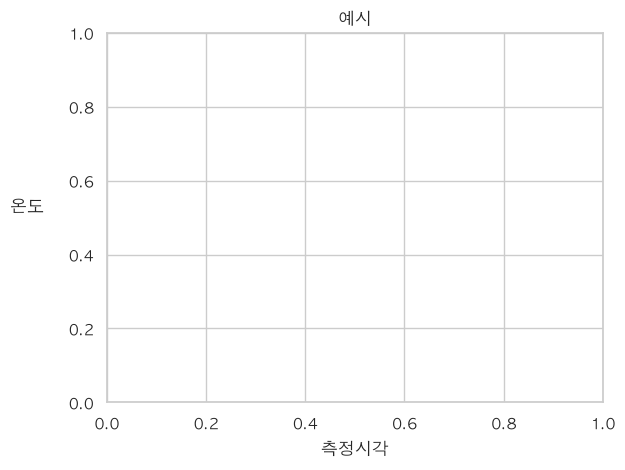

In [9]:
plt.title('예시')
plt.xlabel('측정시각')

plt.ylabel('온도', rotation=0, labelpad=30)

plt.show()

## 실습 1. 환경 준비와 첫 그래프
한글 폰트 설정 후 리스트로 첫 선 그래프 출력

목표
- 한글 폰트를 설정하고 리스트로 첫 선 그래프 출력

단계
- pyplot을 plt 별칭으로 불러오기
- rcParams로 한글 폰트를 설정해 글자 깨짐 방지
- 요일·온도 리스트를 plot으로 그리고 화면에 표시

예상 결과
- 오른쪽 위로 상승하는 선 그래프 한 장

Text(0, 0.5, '온도(섭씨)')

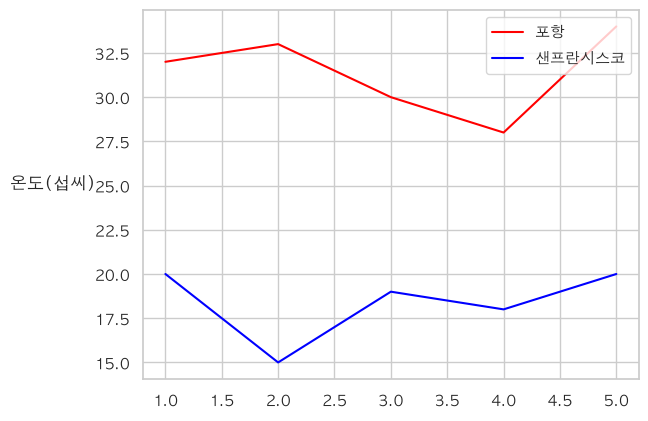

In [10]:
days = [1,2,3,4,5]

weather_pohang = [32, 33, 30, 28, 34]
weather_sf = [20, 15, 19, 18, 20]
plt.plot(days, weather_pohang, label = "포항", color = "red")
plt.plot(days, weather_sf, label = "샌프란시스코", color = "blue")
plt.legend(loc = "upper right")
plt.ylabel("온도(섭씨)", rotation = 0, labelpad=30)

## 실습 2. 선 그래프 직접 그리기
색·선 스타일·마커를 바꿔 가며 선 그래프 그리기

목표
- 색·선 스타일·마커를 바꿔 가며 선 그래프 그리기

단계
- 설비 데이터를 불러와 A호기 행만 고르기
- 일자와 온도로 기본 선 그래프 그리기
- color·linestyle·marker로 선을 꾸며 다시 그리기

예상 결과
- 기본→색→점선·마커 순으로 바뀌는 선 그래프

In [11]:
df = pd.read_csv("/content/17_열처리.csv", encoding = "UTF-8")
df.info()
print()
print(df.head(5))

FileNotFoundError: [Errno 2] No such file or directory: '/content/17_열처리.csv'

In [ ]:
df_A = df[df["배치"] == "로트A"]
df_A.info()

fig, ax = plt.subplots(1,3, figsize=(30, 5))

x = df_A['측정시각']
y = df_A['온도']

ax[0].plot(x, y) # 기본
ax[0].plot(x, df_A["OP값"])
ax[0].plot(x, df_A["CP값"])
# 첫번째 그래프처럼 온도, op값, cp값을 한번에 놓고 보는 것이 옳은 지 항상 고민하고 그래프를 그려야 함
ax[1].plot(x, y, color='red') # 색 변경
ax[2].plot(x, y, color='red', linestyle='--', marker='o') # linestyle 변경


plt.show()

In [ ]:
plt.subplot(311)
plt.plot(x, y) # 기본
plt.plot(x, df_A["OP값"])
plt.plot(x, df_A["CP값"])

plt.subplot(312)
plt.plot(x, y, color='red') # 색 변경

plt.subplot(313)
plt.plot(x, y, color='#00F300', linestyle='--', marker='o') # linestyle 변경


plt.show()

## 실습 3. 센서값 추세 선 그래프
실데이터로 한 설비 추세와 두 설비 비교 그리기

목표
- 실데이터로 한 설비 추세와 두 설비 비교 그리기

단계
- C호기 행을 골라 마커를 붙인 온도 추세 그리기
- A호기와 C호기를 겹쳐 그리고 각 선에 이름표 달기
- legend로 범례를 표시해 어느 선이 어느 설비인지 구분

예상 결과
- C호기 추세와 A·C호기 비교 그래프(범례 포함)

In [ ]:
df_a = df[df['배치'] == '로트A']
df_b = df[df['배치'] == '로트B']
df_c = df[df['배치'] == '로트C']

plt.figure(figsize=(7, 4))

plt.plot(df_a['측정시각'], df_a['온도'], label = '로트A', color = 'green', marker = 's')
plt.plot(df_b['측정시각'], df_b['온도'], label = '로트B', color = 'pink', marker = 'o')
plt.plot(df_c['측정시각'], df_c['온도'], label = '로트C', color = 'gray', linestyle = '--')
plt.legend(loc = "upper right")
plt.ylabel('온도', rotation=0, labelpad=30)
plt.xlabel('측정시각')

plt.savefig('sample.png')
plt.show()
# 이렇게 로트별로 같은 온도계열을 같은 시간대별로 보여주기는 가능하다!

## 실습 4. 제목·축·범례 갖춘 완성형 그래프

제목·축 이름·범례를 모두 갖춘 읽히는 그래프 완성

단계
- figsize로 가로로 긴 그래프 틀 만들기(plot보다 먼저)
- 두 설비를 색·마커를 달리해 겹쳐 그리기
_ 제목·가로축·세로축 이름과 범례 위치를 지정

예상 결과
- 제목·축이름·범례를 갖춘 두 설비 비교 그래프

In [ ]:
plt.figure(figsize=(10, 4)) # 전체 그래프의 크기
plt.title('설비별 온도 추세')

plt.plot(df_a['측정시각'], df_a['온도'], label = '로트A', color = 'green', marker = 'x')
plt.plot(df_b['측정시각'], df_b['온도'], label = '로트B', color = 'pink', marker = 'o')
plt.plot(df_c['측정시각'], df_c['온도'], label = '로트C', color = 'gray', linestyle = '--')

plt.legend(loc = "upper right")
plt.ylabel('온도')
plt.xlabel('측정시각')

plt.savefig('sample2.png')
plt.show()

## 실습 5. 다중 센서 비교 그래프와 저장
반복문으로 세 설비를 비교하고 이미지로 저장

단계
- 설비 이름과 색 목록을 반복하며 각 설비 온도 선 그리기
- 제목·축 이름·범례로 그래프를 완성
- savefig로 그래프를 이미지 파일로 저장(show보다 먼저)

예상 결과
- 세 설비 온도 비교 그래프가 파일로 저장

In [ ]:
plt.figure(figsize=(15, 4)) # 전체 그래프의 크기
plt.title('설비별 온도 추세')

names = [ ('로트A', 'orange'),
          ('로트B', 'green'),
          ('로트C', 'pink')]

for (name, color) in names:
  df_name = df[df['배치'] == name]
  plt.plot(df_name['측정시각'], df_name['온도'], label = name, color = color)

plt.legend(loc = "upper right")
plt.ylabel('온도', rotation=0, labelpad=30)
plt.xlabel('측정시각')

plt.savefig('sample3.png')
plt.show()

## 실습 6. 선 그래프 자유 변형
- 한 설비의 여러 센서를 한 그래프에 종합
- 한 설비의 여러 센서를 한 그래프에 종합해 그리기

단계
- C호기의 온도·진동·소음을 한 그래프에 겹쳐 그리기
- 단위가 다른 진동은 배수를 곱해 눈에 보이게 보정
- 제목·축 이름·범례로 완성하고 함께 움직이는지 관찰

예상 결과
- C호기 온도·진동·소음이 함께 상승하는 종합 그래프

In [ ]:
plt.figure(figsize=(10, 4)) # 전체 그래프의 크기
plt.title('설비별 추세')

plt.plot(df_c['측정시각'], df_c['온도'], label = '온도', color = "#00cdac")
plt.plot(df_c['측정시각'], df_c['OP값'] + 800, label = '진동', color = "#ff6f68") # 진동
plt.plot(df_c['측정시각'], df_c['CP값'] * 1000 + 400, label = '소음', color="#ffa23a") # 소음

plt.legend()

plt.ylabel('온도')
plt.xlabel('측정시각')

plt.savefig('sample4.png')

plt.show()


In [ ]:
plt.figure(figsize=(4,4))
plt.bar(["A호기","B호기", "C호기"], [64,70,77],
        color = ["#00cdac","#00cdac", "#ff6f68"],
        width = 0.7) # width는 0-1.0
plt.show()

In [ ]:
plt.figure(figsize=(4,4))
plt.barh(["A호기","B호기", "C호기"], [64,70,77],
        color = ["#00cdac","#00cdac", "#ff6f68"],
        height = 0.7) # width는 0-1.0
plt.show()

## 실습 1. 막대 그래프 직접 그리기
### 목표

범주별 값을 막대로 비교하고 색·방향을 바꿔 강조

단계

- groupby로 설비별 평균 온도를 구해 막대로 그리기
- 색 리스트로 가장 뜨거운 설비만 강조하고 너비 조절
- barh로 가로 막대로 바꾸고 제목·축 이름 붙이기

### 예상 결과

설비별 평균 온도 막대(C호기 최고), 색·가로 변형

In [ ]:
df = pd.read_csv("/content/17_열처리.csv", encoding = "UTF-8")

avg = df.groupby("배치")["온도"].mean()


plt.figure(figsize=(12,4))
plt.subplots_adjust(wspace=0.3) # 간격조정
plt.subplot(121)
plt.title("배치별 평균온도", pad=15)
plt.ylabel("온도", rotation=0, labelpad=15)
plt.bar(avg.index, avg.values,
        color = ["#ffd872","#ffd872","#ff828b"],
        width = 0.7) # width는 0-1.0

plt.subplot(122)
plt.title("배치별 평균온도", pad=15)
plt.ylabel("온도", rotation=0, labelpad=15)
plt.barh(avg.index, avg.values,
        color = ["#ffd872","#ffd872","#ff828b"],
        height = 0.7) # width는 0-1.0
plt.show()

##실습 2. 범주별 집계 막대 그래프
###목표
value_counts·groupby로 집계한 값을 막대로 비교
###단계
- 상태 열의 개수를 세어 막대로 그리기
- 구역으로 그룹을 나눠 평균 진동을 막대로 그리기
- 제목·축 이름을 붙여 완성
###예상 결과
상태 정상 17·점검 4, 구역별 평균 진동 비교

In [ ]:
status = df["상태"].value_counts()

plt.figure(figsize=(12,4))
plt.subplots_adjust(wspace=0.3) # 간격조정
plt.subplot(121)
plt.title("상태별 개수", pad=15)
plt.ylabel("개수", rotation=0, labelpad=15)
plt.bar(status.index, status.values,
        color = ["#ff828b","#ffd872"],
        width = 0.7) # width는 0-1.0

sections = df.groupby("배치")["OP값"].mean()
plt.subplot(122)
plt.title("배치별 평균 진동", pad=15)
plt.ylabel("진동", rotation=0, labelpad=15)
plt.bar(sections.index, sections.values,
        color = ["#ff828b","#ffd872","#ffd872"],
        width = 0.7) # width는 0-1.0

plt.show()

##실습 3. 히스토그램 직접 그리기
###목표
숫자 분포를 히스토그램으로 그리고 bins로 구간 조절
###단계
- 온도 열을 hist로 그려 자동 구간 분포 확인
- bins를 작게·크게 바꿔 구간 수에 따른 모양 비교
- 제목·축 이름을 붙여 완성
###예상 결과
온도 구간별 개수 분포, bins 5·20의 모양 차이

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(df["온도"], bins = 12, color = "green")
plt.xlabel("온도")
plt.ylabel("설비수", rotation=0, labelpad=15)
plt.show()

##실습 4. 센서값 분포 히스토그램
###목표
분포를 그리고 평균·표준편차와 이상 설비로 해석
###단계
- 온도 분포를 히스토그램으로 그리기
- 평균과 표준편차를 구해 분포의 중심·퍼짐과 비교
- 조건 필터링으로 정상 범위를 벗어난 설비 수 확인
###예상 결과
온도 평균 70.0·표준편차 5.6, 78 이상 설비 2대

In [ ]:
print(f"평균 온도 : {round(df["온도"].mean(),2)}")
print(f"표준편차 : {round(df["온도"].std(),2)}")
high = df[df["온도"] > 862]
print(f"862도 이상 : {len(high)}개")

plt.figure(figsize=(8,4))
plt.hist(df["온도"], bins = 12, color = "green")
plt.xlabel("온도")
plt.ylabel("설비수", rotation=0, labelpad=15)
plt.show()

##실습 5. 산점도로 센서 간 관계 분석
##목표
두 변수 산점도에 상태별 색과 임계 기준선 추가
##단계
- 온도와 진동을 산점도로 찍어 관계 확인
- 상태를 색으로 매핑해 점검·정상을 색으로 구분
- axhline으로 진동 임계 기준선 그리기
##예상 결과
온도↑ 진동↑ 양의 관계, 상태별 색·기준선 표시

In [ ]:
# 산점도

plt.figure(figsize=(8,4))
colors = df["상태"].map({"정상":"Blue", "승온" : "red"})
plt.scatter(df["온도"], df["OP값"], color=colors, alpha=0.4)
plt.axhline(y=90.0, color="green", linestyle="--") # 수평 horizon 라인
plt.axvline(x=862.0, color="green", linestyle="--") # 수직 vertical 라인
plt.xlabel("온도")
plt.ylabel("소음", rotation=0, labelpad=15)
plt.show()

##실습 6. 두 변수 관계 자유 분석
###목표
스스로 고른 두 센서의 관계를 산점도로 분석
###단계
- 관심 있는 두 센서 열을 고르기
- 산점도로 두 값의 관계를 점으로 확인
- 제목·축 이름을 붙이고 관계 방향을 해석
###예상 결과
온도와 소음의 관계 산점도(함께 오르는지 확인)

In [ ]:
plt.figure(figsize=(8,4))
colors = df["상태"].map({"정상":"Blue", "승온" : "red"})
plt.scatter(df["온도"], df["CP값"], color=colors, alpha=0.4)
plt.xlabel("온도")
plt.ylabel("진동", rotation=0, labelpad=15)
plt.show()

##실습 7. *17_열처리_공정.csv* 불러오기와 기초 확인
###목표
실제 공정 데이터를 불러와 크기·결측을 확인하고 처리
###단계
- *17_열처리_공정.csv* 데이터를 불러와 크기와 전체 결측 개수 확인
- 평균으로 결측을 채워 처리
- 처리 후 결측이 0인지 검증
###예상 결과


In [ ]:
df_wide = pd.read_csv("/content/17_열처리_공정.csv", encoding = "UTF-8")
print(df_wide.shape)
print(df_wide.isna().sum()) # 컬럼별 결측
print(df_wide.isna().sum().sum())

df_wide_fill = df_wide.fillna(df_wide.mean(numeric_only=True)) # 숫자형만 골라서 평균으로 결측값 대치
print(df_wide_fill.isna().sum().sum())

##실습 8. 시각화 리포트 완성과 저장
###목표
분포·범주·관계 그래프를 2×2로 모아 리포트로 저장
###단계
- figure와 subplot으로 2×2 칸을 만들기
- 각 칸에 분포·범주·관계·판정 그래프를 그리고 제목 달기
- tight_layout으로 정리하고 이미지 파일로 저장
###예상 결과
센서 분포·라인 개수·관계·판정을 담은 2×2 리포트 저장

In [ ]:
plt.figure(figsize=(8,8))
plt.suptitle("종합리포트", color="#ff828b")
plt.subplots_adjust(wspace=0.3, hspace=0.3) # 간격조정

plt.subplot(2,2,1)
plt.plot([1,2,3,4,5], [11,22,33,44,55])
plt.title("선그래프")

plt.subplot(2,2,2)
plt.bar([1,2,3,4,5], [11,22,33,44,55])
plt.title("막대그래프")

plt.subplot(2,2,3)
plt.hist([1,2,2,2,3,4,4,4,4])
plt.title("히스토그램")

plt.subplot(2,2,4)
plt.scatter([1,2,3,4,5,2,3,2,2,2], [11,22,33,44,55,11,22,10,30,17])
plt.title("산점도")

plt.show()


In [ ]:
plt.figure(figsize=(8,8))
plt.suptitle("종합리포트", color="RED")
# plt.subplots_adjust(wspace=0.3, hspace=0.3) # 간격조정

plt.subplot(2,2,1)
plt.hist(df_wide_fill["소입로온도1존"], bins=15)
plt.xlabel("소입로온도1존")
plt.title("소입로온도1존 분포")

plt.subplot(2,2,2)
counts = df_wide_fill["라인"].value_counts()
bar = plt.bar(counts.index, counts.values)
plt.title("주간/야간별 측정개수")
# 막대그래프에 수치 표시
for rect in bar:
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2.0, height, '%.1f' % height, ha='center', va='bottom', size = 10)


plt.subplot(2,2,3)
plt.scatter(df_wide_fill["소입로온도1존"], df_wide_fill["OP값"], alpha=0.3)
plt.title("소입로온도1존 vs OP값")
plt.xlabel("소입로온도1존")

plt.subplot(2,2,4)
counts_results = df_wide_fill["result"].value_counts()
plt.bar(counts_results.index, counts_results.values)
plt.title("판정결과")

plt.tight_layout()

plt.show()
